In [1]:
import networkx_temporal as tx
import networkx as nx

In [2]:
TG = tx.temporal_graph()
TG.add_edge(1, 2, time=1)
TG.add_edge(1, 2, time=2)
TG.add_edge(2, 3, time=2)
TG.add_edge(3, 4, time=3)
TG.add_edge(3, 4, time=4)
TG.add_edge(3, 5, time=1)
TG.add_edge(3, 5, time=4)
TG.add_edge(3, 6, time=2)
TG.add_edge(5, 6, time=5)
TG.add_edge(6, 7, time=1)
TG.add_edge(6, 7, time=3)

print(TG)

TemporalMultiGraph (t=1) with 7 nodes and 11 edges


In [3]:
TG_slice = TG.slice(attr="time")
print(TG_slice)

TemporalMultiGraph (t=5) with 7 nodes and 11 edges


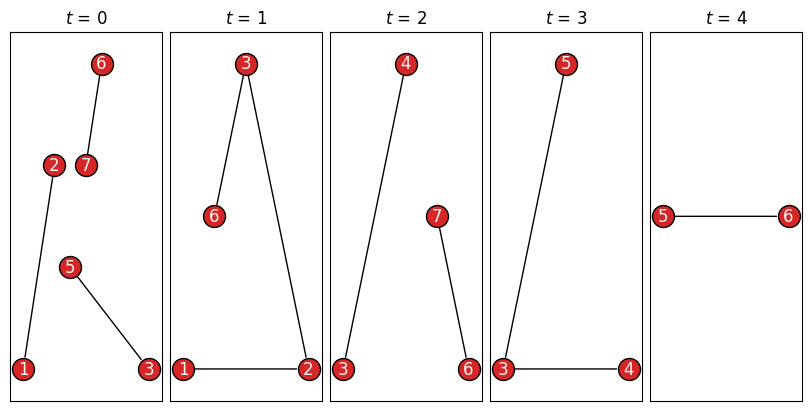

In [4]:
fig = tx.draw_networkx(TG_slice,figsize=(8,4),layout="planar",ncols=5,border=True)
fig

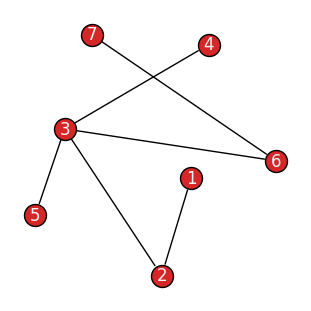

In [5]:
I_s = 1
I_e = 3

H = nx.Graph()


for edge_batch in TG.edges(data=True):
    for u,v,data in edge_batch:
        if I_s <= data["time"] <= I_e:
            H.add_edge(u,v,**data)

tx.draw(H,with_labels=True,layout="arf")

In [6]:
G = nx.Graph()

G.add_edge('V1', 'V2', timestamps=[2,3,4])
G.add_edge('V1', 'V4', timestamps=[4,5,6])
G.add_edge('V1', 'V3', timestamps=[1,2,3,4])
G.add_edge('V2', 'V3', timestamps=[1,2,3,7])
G.add_edge('V2', 'V4', timestamps=[2, 3, 4])
G.add_edge('V3', 'V4', timestamps=[1,2,3,7])
G.add_edge('V3', 'V5', timestamps=[1,2,7])
G.add_edge('V4', 'V5', timestamps=[7])
G.add_edge('V5', 'V6', timestamps=[2,3,4,5])
G.add_edge('V5', 'V8', timestamps=[2,4,6,7])
G.add_edge('V8', 'V6', timestamps=[2,3,5,6,7])
G.add_edge('V8', 'V7', timestamps=[2,5,6,7])
G.add_edge('V6', 'V7', timestamps=[2,3,5])

TG1 = tx.from_static(G)


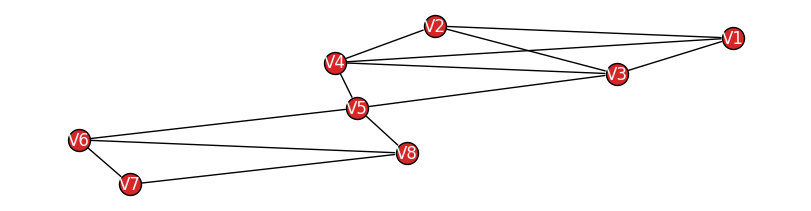

In [7]:
# plot snapshot con tx.draw
fig = tx.draw(TG1,layout="kamada_kawai",figsize=(8,2))

fig

In [8]:
TG2 = tx.temporal_graph()

TG2.add_edge("A", "B", time=1)
TG2.add_edge("A", "B", time=2)
TG2.add_edge("A", "C", time=1)
TG2.add_edge("B", "C", time=3)
TG2.add_edge("C", "D", time=4)
TG2.add_edge("C", "E", time=1)
TG2.add_edge("C", "E", time=3)
TG2.add_edge("C", "E", time=4)


TG2 = TG2.slice(attr="time")
print(TG2)

TemporalMultiGraph (t=4) with 5 nodes and 8 edges


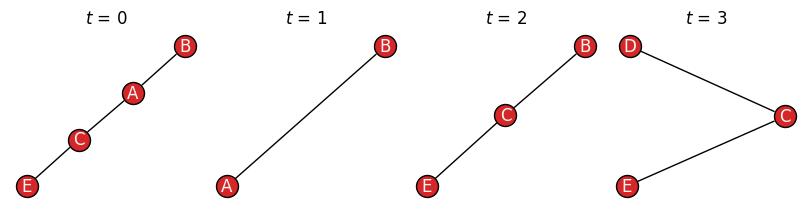

In [9]:
# plot snapshot con tx.draw
fig = tx.draw(TG2,layout="kamada_kawai",figsize=(8,2))

fig

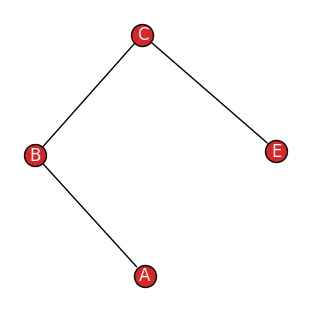

In [11]:
I_s = 2
I_e = 3

H = nx.Graph()


for edge_batch in TG2.edges(data=True):
    for u,v,data in edge_batch:
        if I_s <= data["time"] <= I_e:
            H.add_edge(u,v,**data)

tx.draw(H,with_labels=True,layout="arf")